# Do LLMs Fail the Same Way?
## A Unified Study of Attention and Learning Failures in Large Language Models

Large Language Models (LLMs) often achieve strong results on standard benchmarks, but their failures remain difficult to understand. In many real-world settings, models are exposed to noisy prompts, conflicting instructions, delayed supervision, and structurally complex reasoning tasks. Under such conditions, performance can degrade sharply.

This project studies whether failures in **attention** and **learning** are separate phenomena or whether they emerge from deeper, shared structural weaknesses.

We evaluate four open-source models:

- **Gemma**
- **Llama**
- **Qwen**
- **Mistral**

Across two controlled benchmark families:

### 1. Attention benchmark
This benchmark stresses:
- distraction handling
- positional bias
- instruction interference
- sensitivity to misleading or irrelevant context

### 2. Hard learning benchmark
This benchmark stresses:
- conflicting mappings
- belief updating
- delayed supervision
- exception handling

Beyond descriptive performance analysis, we also train classical machine learning models to predict when LLMs will fail. This helps us test whether failures are random or systematically driven by prompt structure.

### Main question
> Are attention failures and learning failures fundamentally different, or are they driven by the same underlying structural factors?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from scipy.stats import f_oneway, ttest_ind

plt.style.use("default")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Data Loading

The notebook uses two categories of benchmark outputs:

### Attention benchmark outputs
These are the model predictions on prompts that vary across:
- noise type
- target position
- conflict strength

### Hard learning benchmark outputs
These are the model predictions on tasks involving:
- conflicting mappings
- belief updates
- delayed supervision
- exception rules

All model result files are loaded separately and then merged into unified analysis tables.

In [2]:
# -----------------------------
# Paths
# -----------------------------
att_path = "/kaggle/input/datasets/chanduesukula/attention-results/"
learn_path = "/kaggle/input/datasets/chanduesukula/learning-results/"

# -----------------------------
# Load attention benchmark results
# -----------------------------
att_gemma = pd.read_csv(att_path + "attention_benchmark_v8_gemma_results.csv")
att_llama = pd.read_csv(att_path + "attention_benchmark_v8_llama_results.csv")
att_qwen = pd.read_csv(att_path + "attention_benchmark_v8_qwen_results.csv")
att_mistral = pd.read_csv(att_path + "attention_benchmark_v8_mistral_results.csv")

# -----------------------------
# Load hard learning benchmark results
# -----------------------------
learn_gemma = pd.read_csv(learn_path + "learning_hard_gemma_results.csv")
learn_llama = pd.read_csv(learn_path + "learning_hard_llama_results.csv")
learn_qwen = pd.read_csv(learn_path + "learning_hard_qwen_results.csv")
learn_mistral = pd.read_csv(learn_path + "learning_hard_mistral_results.csv")

print("Datasets loaded successfully.")
print("Attention example shape:", att_gemma.shape)
print("Learning example shape:", learn_gemma.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/chanduesukula/attention-results/attention_benchmark_v8_gemma_results.csv'

In [ ]:
# Add model labels
for df, name in zip(
    [att_gemma, att_llama, att_qwen, att_mistral],
    ["gemma", "llama", "qwen", "mistral"]
):
    df["model"] = name

for df, name in zip(
    [learn_gemma, learn_llama, learn_qwen, learn_mistral],
    ["gemma", "llama", "qwen", "mistral"]
):
    df["model"] = name

attention = pd.concat([att_gemma, att_llama, att_qwen, att_mistral])
learning = pd.concat([learn_gemma, learn_llama, learn_qwen, learn_mistral])

attention["task_type"] = "attention"
learning["task_type"] = "learning"

print(attention.shape, learning.shape)

(2240, 23) (480, 14)


## Labeling Model Identity and Building Unified Tables

To make cross-model comparison easier, we attach a `model` label to each dataset and concatenate them.

We also add a `task_type` column so that attention and learning can later be combined into one unified table.

In [ ]:
# -----------------------------
# Add model labels
# -----------------------------
att_gemma["model"] = "gemma"
att_llama["model"] = "llama"
att_qwen["model"] = "qwen"
att_mistral["model"] = "mistral"

learn_gemma["model"] = "gemma"
learn_llama["model"] = "llama"
learn_qwen["model"] = "qwen"
learn_mistral["model"] = "mistral"

# -----------------------------
# Combine within benchmark type
# -----------------------------
attention = pd.concat([att_gemma, att_llama, att_qwen, att_mistral], ignore_index=True)
learning = pd.concat([learn_gemma, learn_llama, learn_qwen, learn_mistral], ignore_index=True)

# -----------------------------
# Add task type
# -----------------------------
attention["task_type"] = "attention"
learning["task_type"] = "learning"

print("Attention total:", attention.shape)
print("Learning total:", learning.shape)
print("\nAttention model distribution:")
print(attention["model"].value_counts())
print("\nLearning model distribution:")
print(learning["model"].value_counts())

Attention total: (2240, 23)
Learning total: (480, 14)

Attention model distribution:
model
gemma      560
llama      560
qwen       560
mistral    560
Name: count, dtype: int64

Learning model distribution:
model
gemma      120
llama      120
qwen       120
mistral    120
Name: count, dtype: int64


## Quick Data Inspection

Before moving into analysis, we inspect a few rows from each merged dataset to verify that:
- the key metadata columns are present
- the `model` label has been added correctly
- the `correct` column is available for downstream analysis

In [ ]:
print("Attention sample:")
display(attention.head(3))

print("Learning sample:")
display(learning.head(3))

Attention sample:


,question_id,attention_module,task_family,variant_family,task_complexity,signal_density,noise_family,noise_length,target_position,conflict_strength,dominant_signal_type,dominant_signal_answer,context_length_bucket,distance_to_target,split,clean_prompt,noisy_prompt,gold_answer,model_output,model_output_clean,correct,model,task_type
0,A3_GEN008_V8,sustained_attention,sustained_attention,noisy,high,medium,instructional_interference,medium,end,strong,misleading_instruction,week,medium,near,train,Read carefully. Ignore all filler. Return ONLY...,Read carefully. Ignore all filler. Return ONLY...,otter,week \n,week,False,gemma,attention
1,A2_GEN027_V2,attention_shifting,attention_shifting,noisy,high,low,random_irrelevant,long,middle,weak,task_instruction,NaN,long,far,train,Use ONLY the FINAL decision rule.\nRule 1: If ...,Penguins live in cold regions. Bananas are yel...,NOT_PRIME,Here's how we apply the rules to determine the...,here's how we apply the rules to determine the...,True,gemma,attention
2,A5_GEN026_V5,stimulus_driven_attention,stimulus_driven_attention,noisy,medium,low,stale_context,medium,beginning,strong,earlier_context,ATLANTA,medium,far,train,Return ONLY the correct answer.\nThe valid cit...,Earlier worksheet answer: ATLANTA. That answer...,SEATTLE,SEATTLE \n,seattle,True,gemma,attention


Learning sample:


,question_id,learning_module,task_family,noise_family,target_position,conflict_strength,clean_prompt,noisy_prompt,gold_answer,model_output,model_output_clean,correct,model,task_type
0,LH_CONFLICT001_V0,learning_hard,conflicting_mapping,none,none,none,Learn the mapping from the examples below.\n\n...,Learn the mapping from the examples below.\n\n...,zop,zop \n,zop,True,gemma,learning
1,LH_CONFLICT001_V1,learning_hard,conflicting_mapping,random_irrelevant,beginning,weak,Learn the mapping from the examples below.\n\n...,Penguins live in cold regions. Bananas are yel...,zop,zop \n,zop,True,gemma,learning
2,LH_CONFLICT001_V2,learning_hard,conflicting_mapping,emotional_salient,beginning,medium,Learn the mapping from the examples below.\n\n...,IMPORTANT: Think carefully before answering.\n...,zop,zop \n,zop,True,gemma,learning


# Part I — Attention Benchmark Analysis

We begin with the attention benchmark.

The attention benchmark is designed to probe how models allocate focus under stress. It includes:
- irrelevant but salient information
- misleading context
- conflicting instructions
- positional manipulations

The goal is to determine whether failures are driven by:
- model quality
- prompt structure
- noise type
- target position

In [ ]:
att_model_acc = attention.groupby("model")["correct"].mean().sort_values(ascending=False)
print(att_model_acc)

model
gemma      0.783929
qwen       0.744643
llama      0.717857
mistral    0.526786
Name: correct, dtype: float64


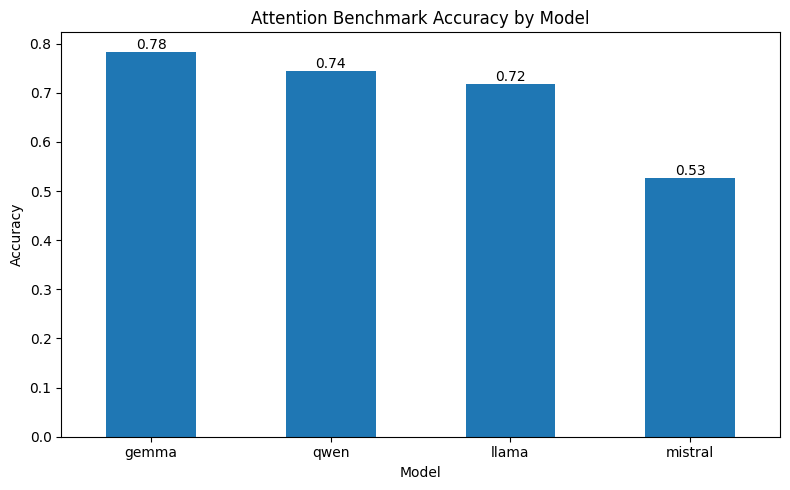

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
att_model_acc.plot(kind="bar", ax=ax)

ax.set_title("Attention Benchmark Accuracy by Model")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Model")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Interpretation

The results indicate a pronounced separation in model performance on attention-intensive tasks.

Gemma achieves the highest accuracy (**0.7839**), followed by Qwen (**0.7446**) and Llama (**0.7179**), while Mistral exhibits a substantial performance deficit (**0.5268**). The magnitude of this gap—over **25 percentage points between Gemma and Mistral**—suggests that these differences are not attributable to random variation, but instead reflect systematic differences in model capability.

From a behavioral perspective, this divergence implies that attention robustness is not uniformly distributed across architectures. Instead, it appears to depend on a model’s ability to:

- selectively prioritize relevant information under competing signals  
- maintain instruction fidelity in the presence of distractors  
- resolve conflicts introduced by misleading or adversarial context  

The comparatively weaker performance of Mistral indicates a higher sensitivity to interference, particularly in scenarios where multiple competing signals must be reconciled. In contrast, Gemma’s performance suggests more stable context integration and stronger resistance to disruption.

Importantly, the persistence of this ranking across the benchmark indicates that these differences are structural rather than incidental.

### Takeaway

> Model performance on attention tasks is governed by underlying differences in contextual processing and resistance to interference, rather than by task-specific variability.

In [ ]:
att_noise = attention.groupby("noise_family")["correct"].mean().sort_values(ascending=False)
print(att_noise)

noise_family
misleading_context            0.831707
none                          0.817073
emotional_salient             0.795455
stale_context                 0.779528
random_irrelevant             0.736726
instructional_interference    0.342324
Name: correct, dtype: float64


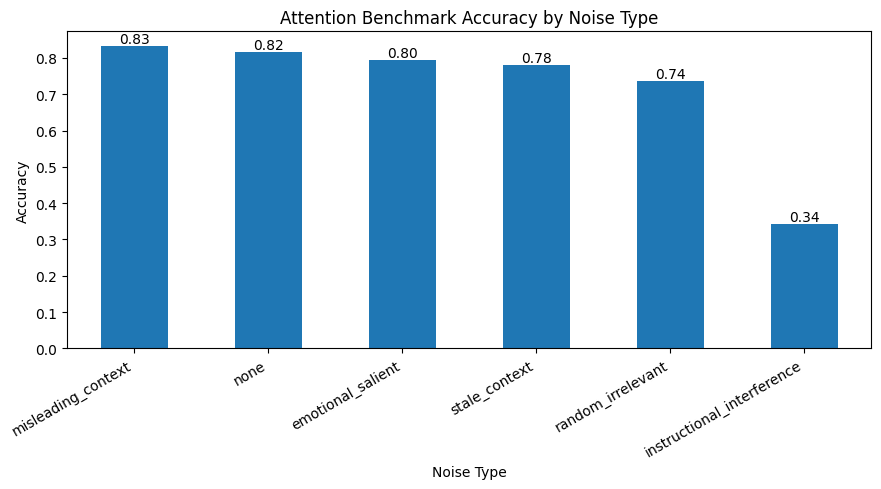

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
att_noise.plot(kind="bar", ax=ax)

ax.set_title("Attention Benchmark Accuracy by Noise Type")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Noise Type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Interpretation

The results reveal a highly asymmetric impact of different noise types on model performance.

Most noise categories—such as misleading context (**0.8317**), no noise (**0.8171**), emotional salience (**0.7955**), and stale context (**0.7795**)—result in relatively high and tightly clustered accuracy levels. Even random irrelevant noise (**0.7367**) produces only a moderate degradation.

In stark contrast, **instructional interference** leads to a dramatic collapse in performance (**0.3423**), representing a drop of nearly **40–50 percentage points** relative to other conditions.

This disparity is critical. Unlike other noise types, instructional interference does not merely introduce irrelevant or misleading information—it directly **competes with the original task objective**. As a result, the model is forced to reconcile conflicting directives, such as:

- overriding earlier instructions  
- prioritizing later instructions that contradict the task  
- resolving ambiguity in instruction hierarchy  

The sharp performance drop suggests that models lack a stable mechanism for **instruction prioritization and conflict resolution**. Instead of consistently following the intended task, they appear sensitive to surface-level cues that can override earlier context.

### Key Insight

> Not all noise is equally harmful — **instructional interference represents a fundamentally different failure mode**, where the model’s control flow over instructions breaks down.

### Takeaway

> LLM failures under noise are not driven primarily by distraction, but by the inability to reliably resolve competing instructions within the prompt.

In [ ]:
position_order = ["none", "beginning", "middle", "end"]
att_pos = attention.groupby("target_position")["correct"].mean().reindex(position_order)
print(att_pos)

target_position
none         0.817073
beginning    0.729846
middle       0.778547
end          0.204000
Name: correct, dtype: float64


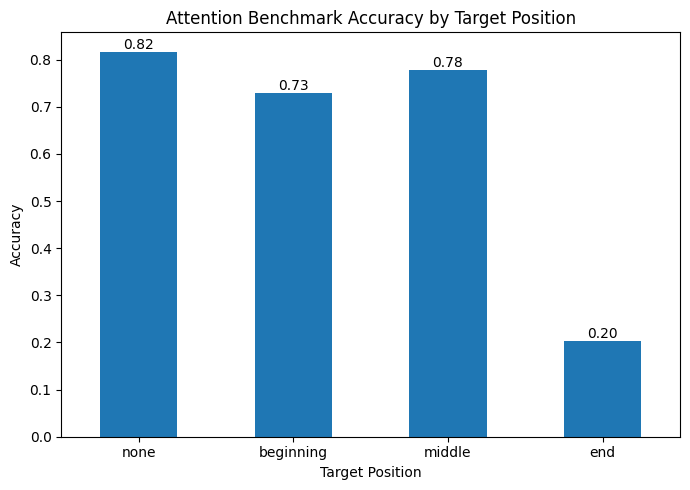

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
att_pos.plot(kind="bar", ax=ax)

ax.set_title("Attention Benchmark Accuracy by Target Position")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Target Position")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Interpretation

The aggregated results by `target_position` reveal a pronounced positional effect on model performance.

Accuracy remains relatively high when the relevant signal appears at the **beginning** (**0.7298**) or **middle** (**0.7785**) of the prompt, and is highest when no positional manipulation is applied (**0.8171**). However, performance collapses dramatically when the signal is placed at the **end** of the prompt, dropping to **0.2040**.

This represents a reduction of over **50 percentage points**, making it the largest performance degradation observed across any single experimental factor in the attention benchmark.

Unlike noise effects, which vary in magnitude, this pattern is consistent and structural. The sharp decline suggests that models struggle to retain or prioritize task-relevant information when it appears late in the input sequence.

From a mechanistic perspective, this behavior points to limitations in:

- maintaining long-range dependencies within the prompt  
- preserving instruction hierarchy across the sequence  
- consistently attending to late-arriving critical information  

Rather than exhibiting uniform attention across the input, models appear biased toward earlier context, leading to a failure to incorporate essential information when it is delayed.

### Key Insight

> Positional structure exerts a dominant influence on performance, with end-position signals triggering a systematic collapse in accuracy.

### Takeaway

> LLM failures in attention tasks are strongly driven by positional bias, indicating that models are not fully robust to the ordering of information within the prompt.

# Part II — Hard Learning Benchmark Analysis

We now move to the hard learning benchmark.

Unlike the attention benchmark, this dataset probes whether models can:
- learn or update rules
- resolve conflicting mappings
- handle exceptions
- apply delayed supervision

This benchmark is more cognitively demanding than standard in-context learning tasks because it explicitly introduces conflict and revision.

In [ ]:
learn_model_acc = learning.groupby("model")["correct"].mean().sort_values(ascending=False)
print(learn_model_acc)

model
gemma      0.925000
llama      0.833333
qwen       0.783333
mistral    0.458333
Name: correct, dtype: float64


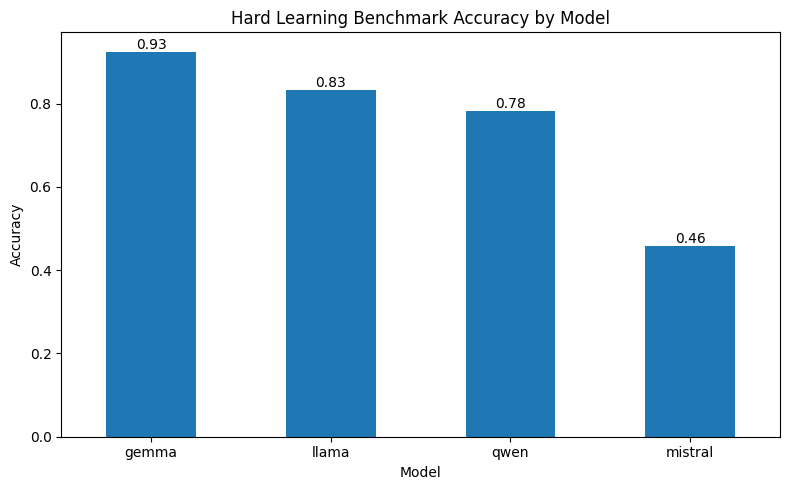

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
learn_model_acc.plot(kind="bar", ax=ax)

ax.set_title("Hard Learning Benchmark Accuracy by Model")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Model")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Interpretation

The aggregated model-level results on the hard learning benchmark reveal a clear and consistent performance ordering.

Gemma achieves the highest accuracy (**0.9250**), followed by Llama (**0.8333**) and Qwen (**0.7833**), while Mistral again exhibits substantially lower performance (**0.4583**). The gap between the strongest and weakest model exceeds **45 percentage points**, indicating a pronounced difference in learning capability.

Importantly, this ranking closely mirrors the pattern observed in the attention benchmark. Despite the increased cognitive demands of the learning tasks—such as rule updating, conflict resolution, and exception handling—the relative ordering of models remains stable.

This consistency suggests that model robustness is not confined to a specific task domain. Instead, it reflects broader architectural and alignment-related properties that generalize across different types of reasoning challenges.

From a behavioral perspective, stronger models appear better equipped to:

- maintain consistency when rules are updated  
- resolve conflicting mappings without collapsing performance  
- integrate new information without overwriting prior context  

In contrast, weaker models exhibit significant degradation under these conditions, indicating limited capacity for stable rule application and conflict resolution.

### Key Insight

> The persistence of the same performance hierarchy across attention and learning tasks indicates that model robustness is a global property rather than a task-specific trait.

### Takeaway

> Differences in model performance reflect underlying differences in reasoning stability and generalization, not just sensitivity to a particular benchmark.

In [ ]:
learn_task = learning.groupby("task_family")["correct"].mean().sort_values(ascending=False)
print(learn_task)

task_family
belief_update          0.891667
delayed_supervision    0.825000
exception_rule         0.716667
conflicting_mapping    0.566667
Name: correct, dtype: float64


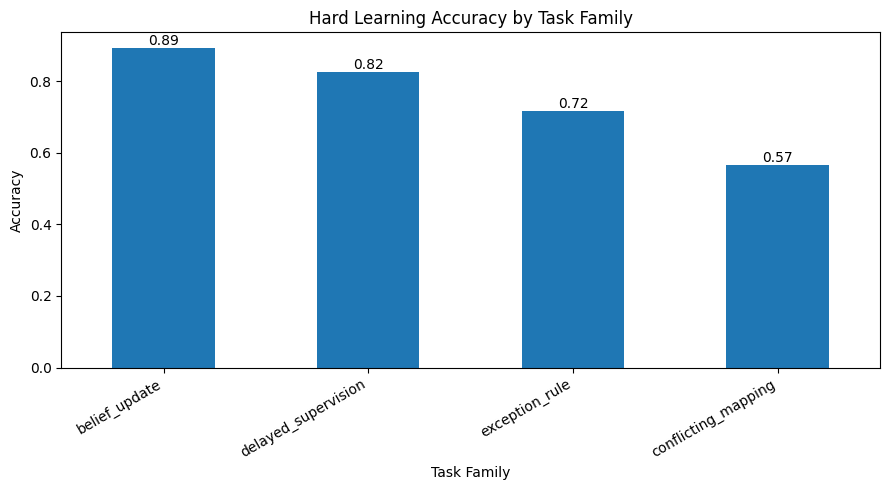

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
learn_task.plot(kind="bar", ax=ax)

ax.set_title("Hard Learning Accuracy by Task Family")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Task Family")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Interpretation

The aggregated results across `task_family` reveal a clear gradient in task difficulty within the hard learning benchmark.

Models perform best on **belief update** tasks (**0.8917**) and **delayed supervision** (**0.8250**), indicating a strong ability to incorporate new information and apply it after a delay. Performance declines for **exception rule** tasks (**0.7167**), and drops most sharply for **conflicting mapping** tasks (**0.5667**), which represent the most challenging condition.

This pattern suggests that models are not uniformly limited in their learning ability. Instead, their performance degrades specifically in scenarios that require **conflict resolution between competing rules**.

In belief update and delayed supervision settings, the model can integrate new information without needing to reconcile contradictions. However, in conflicting mapping tasks, the model must:

- revise or override previously learned associations  
- maintain internal consistency across competing mappings  
- avoid interference between old and new rules  

The substantial performance drop in this condition indicates that models struggle to maintain stable rule representations when faced with direct conflict.

### Key Insight

> The primary difficulty in hard learning tasks is not acquiring new rules, but resolving conflicts between competing mappings.

### Takeaway

> LLMs exhibit limitations in **consistent rule revision and conflict handling**, highlighting a gap between pattern learning and robust, structured reasoning.

In [ ]:
learn_noise = learning.groupby("noise_family")["correct"].mean().sort_values(ascending=False)
print(learn_noise)

noise_family
emotional_salient             0.8750
none                          0.8750
misleading_context            0.8375
random_irrelevant             0.7750
stale_context                 0.7000
instructional_interference    0.4375
Name: correct, dtype: float64


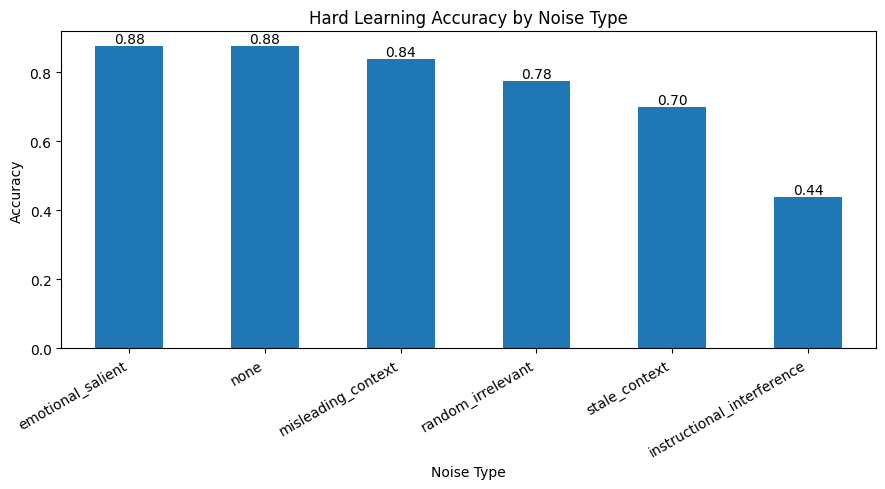

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
learn_noise.plot(kind="bar", ax=ax)

ax.set_title("Hard Learning Accuracy by Noise Type")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Noise Type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Interpretation

The aggregated results across `noise_family` in the hard learning benchmark show a consistent pattern in how different types of noise affect performance.

Most noise conditions—such as emotional salience (**0.8750**), no noise (**0.8750**), and misleading context (**0.8375**)—result in relatively high accuracy. Even random irrelevant noise (**0.7750**) and stale context (**0.7000**) produce only moderate degradation.

However, **instructional interference** again emerges as a clear outlier, with accuracy dropping sharply to **0.4375**. This represents a decline of over **40 percentage points** compared to the best-performing conditions.

This pattern closely mirrors the behavior observed in the attention benchmark, indicating that the impact of noise is consistent across both domains. In particular, noise types that introduce distraction or irrelevant information have limited effect, whereas noise that introduces **conflicting instructions** leads to substantial performance breakdown.

From a behavioral perspective, this suggests that models are not primarily limited by their ability to filter noise, but by their ability to **resolve competing directives within the prompt**.

### Key Insight

> Instructional interference consistently produces the largest performance degradation across both attention and learning tasks, indicating a shared failure mode driven by instruction conflict.

### Takeaway

> LLM performance under noisy conditions is governed less by distraction and more by the ability to manage and prioritize conflicting instructions.

In [ ]:
learn_pos = learning.groupby("target_position")["correct"].mean().reindex(["none", "beginning", "end"])
print(learn_pos)

target_position
none         0.875000
beginning    0.796875
end          0.437500
Name: correct, dtype: float64


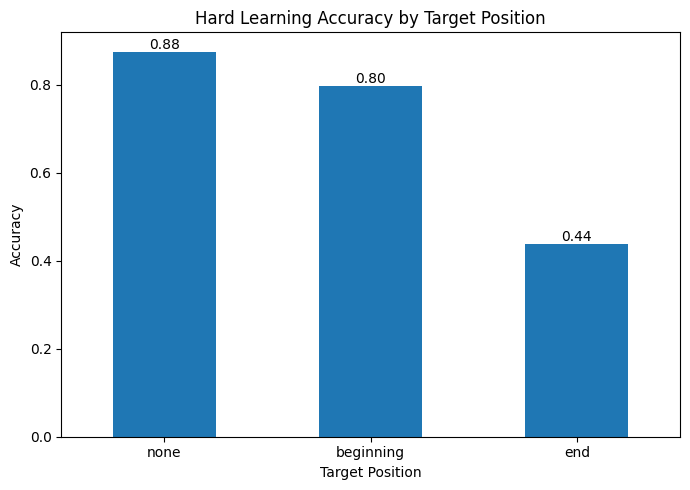

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
learn_pos.plot(kind="bar", ax=ax)

ax.set_title("Hard Learning Accuracy by Target Position")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Target Position")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Interpretation

The aggregated results by `target_position` in the hard learning benchmark reveal a strong positional effect on performance.

Accuracy is highest when no positional manipulation is applied (**0.8750**) and remains relatively strong when the signal appears at the **beginning** (**0.7969**). However, performance drops sharply when the signal is placed at the **end**, falling to **0.4375**.

This represents a decline of over **40 percentage points**, indicating a substantial degradation in learning performance when critical information is delayed within the prompt.

Importantly, this pattern closely mirrors the positional effect observed in the attention benchmark, where end-position signals also led to a dramatic collapse. The consistency of this behavior across both domains suggests that positional bias is not limited to attention tasks, but extends to more complex learning scenarios.

From a mechanistic perspective, this indicates that models struggle to:

- retain and apply task-relevant information over longer input sequences  
- preserve the influence of late-arriving signals during reasoning  
- maintain consistent rule application when critical information is introduced late  

This finding is particularly significant because it shows that performance degradation in hard learning is not solely due to task complexity (e.g., conflicting rules), but is also strongly influenced by **how information is structured within the prompt**.

### Key Insight

> Positional bias is a cross-domain failure mechanism, affecting both attention and learning tasks in a consistent and measurable way.

### Takeaway

> LLM performance is highly sensitive to input ordering, indicating that effective reasoning depends not only on task complexity but also on the placement of information within the prompt.

# Part III — Unified Attention + Learning Analysis

We now combine both datasets into a single table.

This lets us ask a more powerful question:

> Are attention and learning failures fundamentally different, or are they driven by the same structural variables?

In [ ]:
full_data = pd.concat([attention, learning], ignore_index=True)

print("Combined shape:", full_data.shape)
display(full_data.head())

Combined shape: (2720, 24)


,question_id,attention_module,task_family,variant_family,task_complexity,signal_density,noise_family,noise_length,target_position,conflict_strength,dominant_signal_type,dominant_signal_answer,context_length_bucket,distance_to_target,split,clean_prompt,noisy_prompt,gold_answer,model_output,model_output_clean,correct,model,task_type,learning_module
0,A3_GEN008_V8,sustained_attention,sustained_attention,noisy,high,medium,instructional_interference,medium,end,strong,misleading_instruction,week,medium,near,train,Read carefully. Ignore all filler. Return ONLY...,Read carefully. Ignore all filler. Return ONLY...,otter,week \n,week,False,gemma,attention,NaN
1,A2_GEN027_V2,attention_shifting,attention_shifting,noisy,high,low,random_irrelevant,long,middle,weak,task_instruction,NaN,long,far,train,Use ONLY the FINAL decision rule.\nRule 1: If ...,Penguins live in cold regions. Bananas are yel...,NOT_PRIME,Here's how we apply the rules to determine the...,here's how we apply the rules to determine the...,True,gemma,attention,NaN
2,A5_GEN026_V5,stimulus_driven_attention,stimulus_driven_attention,noisy,medium,low,stale_context,medium,beginning,strong,earlier_context,ATLANTA,medium,far,train,Return ONLY the correct answer.\nThe valid cit...,Earlier worksheet answer: ATLANTA. That answer...,SEATTLE,SEATTLE \n,seattle,True,gemma,attention,NaN
3,A3_GEN019_V2,sustained_attention,sustained_attention,noisy,high,low,random_irrelevant,long,middle,weak,task_instruction,NaN,long,far,train,Read carefully. Ignore all filler. Return ONLY...,Penguins live in cold regions. Bananas are yel...,START,START \n,start,True,gemma,attention,NaN
4,A4_GEN041_V6,attention_capacity,attention_capacity,noisy,high,low,misleading_context,medium,middle,strong,recent_context,11,long,far,train,Only the LAST value matters. Return ONLY the f...,Several worked examples above incorrectly conc...,83,83 \n,83,True,gemma,attention,NaN


In [ ]:
task_compare = full_data.groupby(["task_type", "model"])["correct"].mean().unstack()
print(task_compare)

model         gemma     llama   mistral      qwen
task_type                                        
attention  0.783929  0.717857  0.526786  0.744643
learning   0.925000  0.833333  0.458333  0.783333


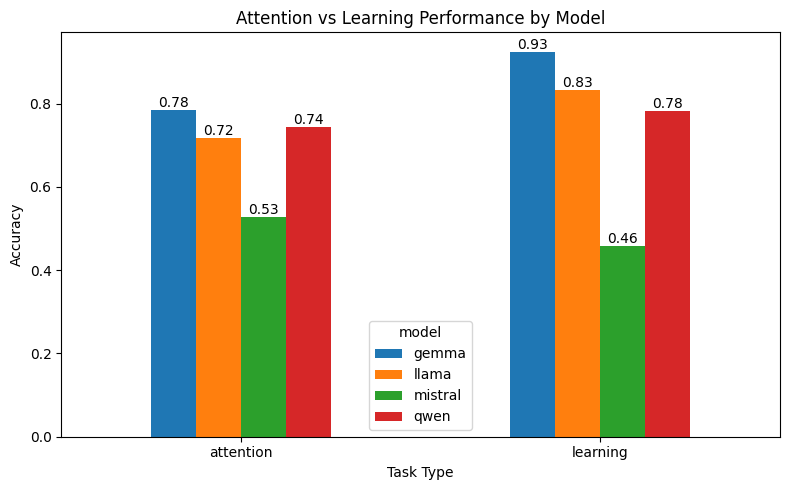

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
task_compare.plot(kind="bar", ax=ax)

ax.set_title("Attention vs Learning Performance by Model")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Task Type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Interpretation

The comparison across task types reveals two important patterns.

First, for the stronger models, performance on the hard learning benchmark exceeds performance on the attention benchmark. For example, Gemma improves from **0.7839** (attention) to **0.9250** (learning), and Llama from **0.7179** to **0.8333**. This suggests that, despite the conceptual complexity of learning tasks, they are not inherently more difficult than attention tasks.

Second, and more importantly, the **relative ordering of models remains unchanged across both domains**. Gemma consistently performs best, followed by Qwen and Llama, while Mistral remains the weakest model in both settings (**0.5268 → 0.4583**).

The persistence of this ranking is highly informative. It indicates that performance differences are not driven by task-specific characteristics, but instead reflect **global properties of the models themselves**, such as:

- robustness to interference  
- stability in processing structured inputs  
- ability to maintain consistent behavior under varying prompt conditions  

From a broader perspective, this result suggests that attention and learning failures are not independent phenomena. Instead, they appear to arise from **shared underlying mechanisms** that govern how models process, prioritize, and integrate information.

### Key Insight

> The consistency of model rankings across both attention and learning benchmarks indicates that LLM performance is governed by general-purpose robustness rather than task-specific capabilities.

### Takeaway

> Attention and learning failures are not fundamentally distinct; they reflect the same underlying structural limitations in how models handle competing information and maintain consistency across context.

# Part IV — Heatmaps for Global Failure Patterns

Heatmaps provide a more compact way to visualize how models respond to:
- noise types
- target position
- task category

These views are useful because they reveal stable cross-model trends that can be difficult to see from single bar charts alone.

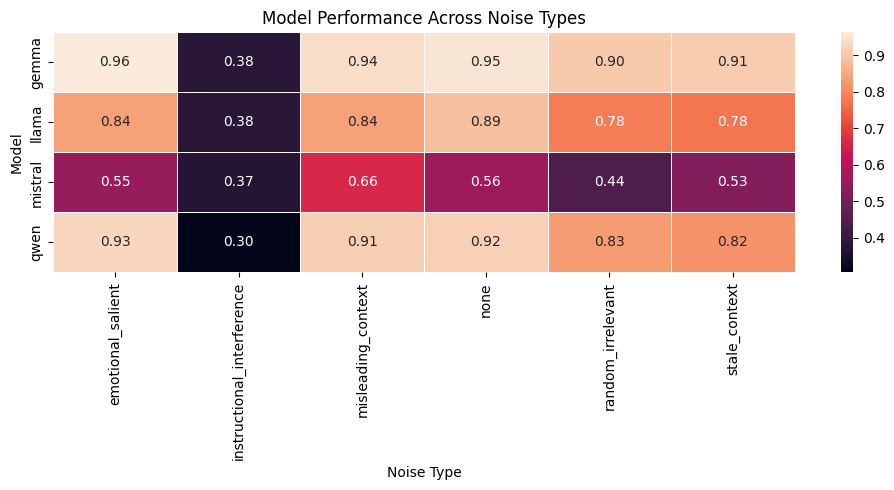

In [ ]:
heatmap_noise = full_data.pivot_table(
    values="correct",
    index="model",
    columns="noise_family",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_noise, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Model Performance Across Noise Types")
plt.ylabel("Model")
plt.xlabel("Noise Type")
plt.tight_layout()
plt.show()

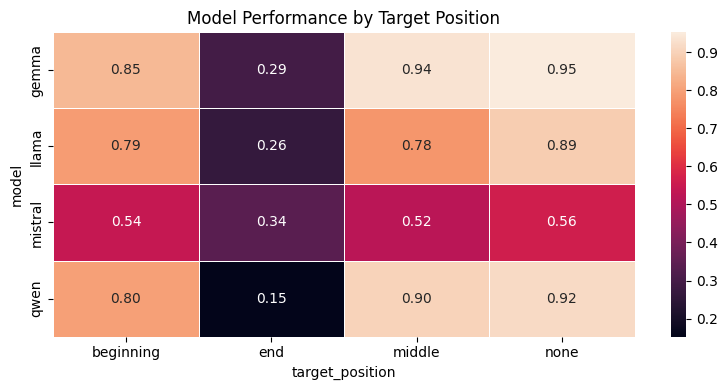

In [ ]:
heatmap_pos = full_data.pivot_table(
    values="correct",
    index="model",
    columns="target_position",
    aggfunc="mean"
)

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_pos, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Model Performance by Target Position")
plt.tight_layout()
plt.show()

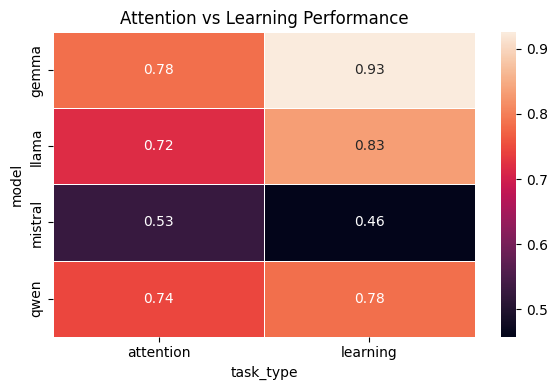

In [ ]:
heatmap_task = full_data.pivot_table(
    values="correct",
    index="model",
    columns="task_type",
    aggfunc="mean"
)

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_task, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Attention vs Learning Performance")
plt.tight_layout()
plt.show()

### Heatmap Interpretation

The heatmaps reinforce three broad conclusions:

1. **Instructional interference** is the most destructive noise across both domains
2. **End-position information** consistently degrades performance
3. Model-level differences are stable across both attention and learning

These patterns suggest that failures are not arbitrary. They reflect repeatable structural weaknesses.

# Part V — Predicting LLM Failures with Classical Machine Learning

Descriptive plots show where failures happen. The next question is whether those failures are **predictable**.

If a simple machine learning model can predict correctness from metadata such as:
- noise type
- position
- conflict strength
- task type
- model identity

then LLM failures are likely systematic rather than random.

In [ ]:
# -----------------------------
# Attention failure prediction
# -----------------------------
att_features = [
    "noise_family",
    "target_position",
    "conflict_strength",
    "model"
]

X_att = attention[att_features]
y_att = attention["correct"]

preprocessor_att = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), att_features)
    ]
)

X_train_att, X_test_att, y_train_att, y_test_att = train_test_split(
    X_att, y_att, test_size=0.2, random_state=42
)

att_rf = Pipeline([
    ("preprocess", preprocessor_att),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
])

att_rf.fit(X_train_att, y_train_att)
att_pred = att_rf.predict(X_test_att)
att_acc = att_rf.score(X_test_att, y_test_att)

print("Attention RF accuracy:", att_acc)
print(classification_report(y_test_att, att_pred))

Attention RF accuracy: 0.7477678571428571
              precision    recall  f1-score   support

       False       0.55      0.46      0.50       124
        True       0.81      0.86      0.83       324

    accuracy                           0.75       448
   macro avg       0.68      0.66      0.67       448
weighted avg       0.74      0.75      0.74       448



### Interpretation

The Random Forest model achieves an accuracy of **0.7478** in predicting attention task outcomes using only structured metadata (noise type, target position, conflict strength, and model identity).

This level of performance is notable because the model does not have access to the underlying prompts or semantic content—it relies solely on high-level features describing the structure of the task. Despite this limitation, it is able to correctly predict outcomes in approximately **75% of cases**.

The classification metrics further reveal an asymmetry in prediction performance. The model achieves strong recall for correct predictions (**0.86**) but lower recall for failures (**0.46**), indicating that while successful cases are relatively predictable, failure cases are more heterogeneous and harder to capture fully.

Importantly, the overall predictive accuracy is substantially higher than a random baseline, demonstrating that model behavior is not stochastic. Instead, correctness is strongly influenced by identifiable structural variables.

### Key Insight

> LLM performance on attention tasks can be predicted from prompt structure alone, without access to semantic content.

### Takeaway

> Attention failures are systematic and structured, rather than random, and can be modeled using classical machine learning techniques.

In [ ]:
# -----------------------------
# Learning failure prediction
# -----------------------------
learn_features = [
    "task_family",
    "noise_family",
    "target_position",
    "conflict_strength",
    "model"
]

X_learn = learning[learn_features]
y_learn = learning["correct"]

preprocessor_learn = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), learn_features)
    ]
)

X_train_learn, X_test_learn, y_train_learn, y_test_learn = train_test_split(
    X_learn, y_learn, test_size=0.2, random_state=42
)

learn_rf = Pipeline([
    ("preprocess", preprocessor_learn),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
])

learn_rf.fit(X_train_learn, y_train_learn)
learn_pred = learn_rf.predict(X_test_learn)
learn_acc = learn_rf.score(X_test_learn, y_test_learn)

print("Learning RF accuracy:", learn_acc)
print(classification_report(y_test_learn, learn_pred))

Learning RF accuracy: 0.8229166666666666
              precision    recall  f1-score   support

       False       0.59      0.77      0.67        22
        True       0.93      0.84      0.88        74

    accuracy                           0.82        96
   macro avg       0.76      0.81      0.77        96
weighted avg       0.85      0.82      0.83        96



### Interpretation

The Random Forest model achieves an accuracy of **0.8229** in predicting outcomes on the hard learning benchmark using only structured metadata.

This performance is notably higher than the attention prediction model (**~0.75**), indicating that learning task outcomes are even more predictable from structural features such as task family, noise type, target position, and conflict strength.

The classification metrics show strong overall performance, particularly for correct predictions (precision **0.93**, recall **0.84**). At the same time, failure cases (False class) exhibit higher recall (**0.77**) compared to the attention model, suggesting that learning failures are more consistently captured by the model.

This difference is important. While attention failures showed some variability, learning failures appear to follow more **stable and identifiable patterns**, making them easier to predict from high-level task characteristics.

Crucially, as with the attention model, the classifier does not have access to prompt content or semantics. Its predictive power comes entirely from structural metadata, reinforcing the idea that performance is governed by **how tasks are constructed**, rather than by randomness.

### Key Insight

> Learning task outcomes are highly predictable from structural features, indicating that failures follow consistent and reproducible patterns.

### Takeaway

> LLM performance in learning tasks is strongly shaped by task design and prompt structure, and can be reliably modeled using classical machine learning approaches.

# Part VI — Unified Failure Modeling Across Both Domains

We now train one unified model across both attention and learning.

This is the most important analysis in the notebook, because it tests whether a common set of features can explain failures in both domains simultaneously.

In [ ]:
combined_features = [
    "task_type",
    "noise_family",
    "target_position",
    "conflict_strength",
    "model"
]

X = full_data[combined_features]
y = full_data["correct"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), combined_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

combined_model = Pipeline([
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
])

combined_model.fit(X_train, y_train)
combined_pred = combined_model.predict(X_test)
combined_acc = combined_model.score(X_test, y_test)

print("Unified model accuracy:", combined_acc)
print("Combined shape:", full_data.shape)
print(full_data["model"].value_counts())
print(classification_report(y_test, combined_pred))

Unified model accuracy: 0.7481617647058824
Combined shape: (2720, 24)
model
gemma      680
llama      680
qwen       680
mistral    680
Name: count, dtype: int64
              precision    recall  f1-score   support

       False       0.67      0.43      0.52       175
        True       0.77      0.90      0.83       369

    accuracy                           0.75       544
   macro avg       0.72      0.66      0.68       544
weighted avg       0.74      0.75      0.73       544



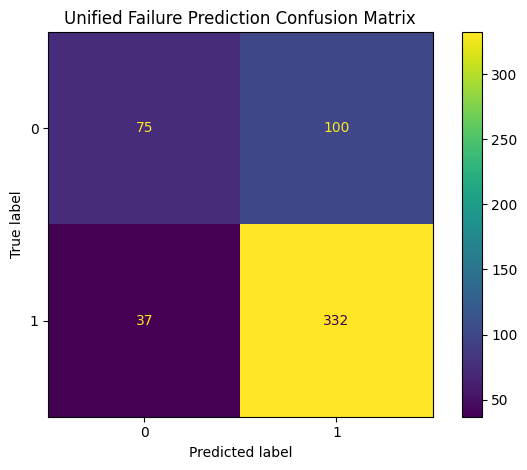

In [ ]:
cm = confusion_matrix(y_test, combined_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Unified Failure Prediction Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
ohe = combined_model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(combined_features)
importances = combined_model.named_steps["rf"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(20))

                                    feature  importance
3   noise_family_instructional_interference    0.256884
18                            model_mistral    0.167122
9                       target_position_end    0.163239
16                              model_gemma    0.057102
14                 conflict_strength_strong    0.056723
19                               model_qwen    0.036525
1                        task_type_learning    0.031860
8                 target_position_beginning    0.031100
17                              model_llama    0.029788
4           noise_family_misleading_context    0.029374
0                       task_type_attention    0.027649
10                   target_position_middle    0.024384
7                noise_family_stale_context    0.024239
12                 conflict_strength_medium    0.020168
2            noise_family_emotional_salient    0.009894
6            noise_family_random_irrelevant    0.009116
5                         noise_family_none    0

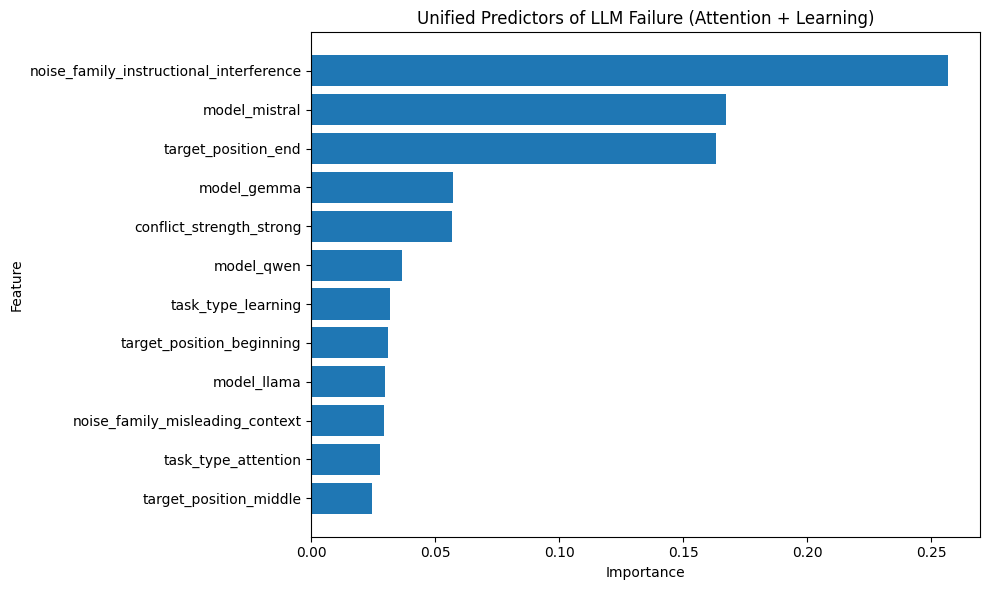

In [ ]:
top = feat_imp.head(12)

plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["importance"])
plt.title("Unified Predictors of LLM Failure (Attention + Learning)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Logistic Regression (Unified)
# -----------------------------

log_reg = Pipeline([
    ("preprocess", preprocessor),
    ("lr", LogisticRegression(max_iter=1000))
])

log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_test)
log_acc = log_reg.score(X_test, y_test)

print("Logistic Regression Accuracy:", log_acc)
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7481617647058824
              precision    recall  f1-score   support

       False       0.70      0.38      0.49       175
        True       0.76      0.92      0.83       369

    accuracy                           0.75       544
   macro avg       0.73      0.65      0.66       544
weighted avg       0.74      0.75      0.72       544



In [ ]:
print("Random Forest Accuracy:", combined_acc)
print("Logistic Regression Accuracy:", log_acc)

Random Forest Accuracy: 0.7481617647058824
Logistic Regression Accuracy: 0.7481617647058824


### Model Comparison

Random Forest and Logistic Regression achieve identical accuracy (**0.7482**), which is a highly informative result.

Because Logistic Regression is a much simpler linear model, this suggests that the main predictors of LLM failure are not only systematic, but also structurally simple enough to be captured without complex nonlinear modeling.

In [ ]:
# -----------------------------
# Logistic Regression Coefficients
# -----------------------------

ohe_lr = log_reg.named_steps["preprocess"].named_transformers_["cat"]
feature_names_lr = ohe_lr.get_feature_names_out(combined_features)

coefficients = log_reg.named_steps["lr"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names_lr,
    "coefficient": coefficients
}).sort_values(by="coefficient", key=abs, ascending=False)

print(coef_df.head(20))

                                    feature  coefficient
3   noise_family_instructional_interference    -1.449041
18                            model_mistral    -0.919968
4           noise_family_misleading_context     0.833236
16                              model_gemma     0.779726
2            noise_family_emotional_salient     0.717998
9                       target_position_end    -0.480792
1                        task_type_learning     0.440318
8                 target_position_beginning     0.433870
19                               model_qwen     0.394253
13                   conflict_strength_none     0.309540
11                     target_position_none     0.309540
5                         noise_family_none     0.309540
17                              model_llama     0.167582
10                   target_position_middle     0.158975
14                 conflict_strength_strong     0.141694
12                 conflict_strength_medium    -0.124857
15                   conflict_s

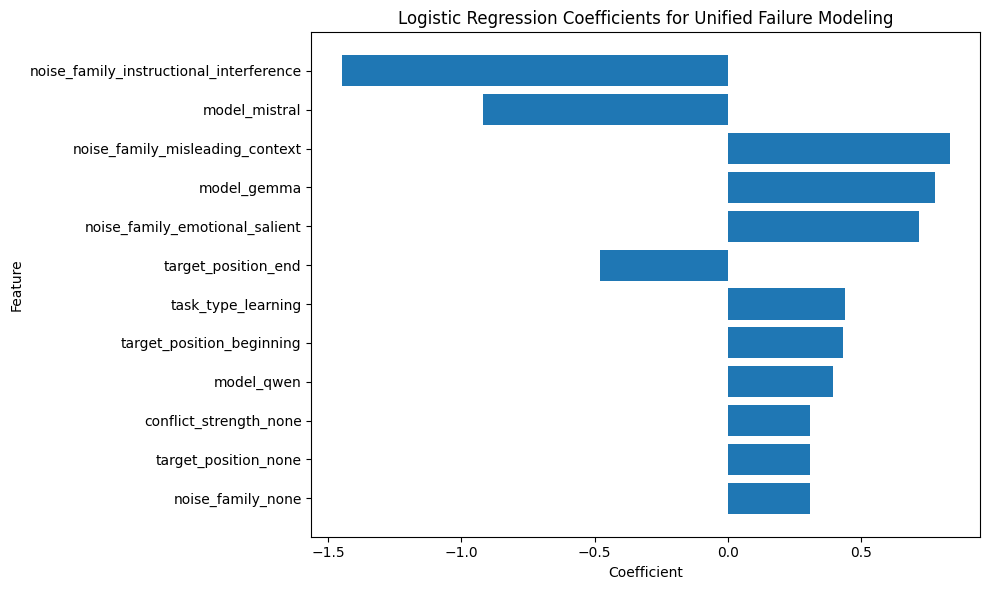

In [ ]:
top_coef = coef_df.head(12)

plt.figure(figsize=(10, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.title("Logistic Regression Coefficients for Unified Failure Modeling")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Unified Model Interpretation

The unified model achieves an accuracy of **0.7482** across both attention and learning tasks, demonstrating that failures in both domains can be predicted using a shared set of structural features.

The Random Forest feature importance analysis identifies a highly consistent set of dominant predictors. The strongest contributors are:

- **instructional interference** (**0.2569**)  
- **model identity**, especially **Mistral** (**0.1671**)  
- **end-position prompts** (**0.1632**)  
- **strong conflict strength** (**0.0567**)  

In contrast, **task type** contributes relatively little to predictive power (roughly **0.03**), indicating that whether a task is labeled as attention or learning is less important than how it is structured.

The Logistic Regression results reinforce this conclusion. Importantly, Logistic Regression achieves the **same accuracy (0.7482)** as Random Forest, despite being a much simpler linear model. This suggests that the relationship between structural features and correctness is not highly nonlinear; instead, failure patterns are governed by strong, stable, and largely linear signals.

The coefficient analysis provides additional directional insight. Features such as:

- **instructional interference** (**-1.4490**)  
- **model_mistral** (**-0.9200**)  
- **target_position_end** (**-0.4808**)  

are strongly associated with failure, while features such as:

- **model_gemma** (**0.7797**)  
- **noise_family_misleading_context** (**0.8332**)  
- **noise_family_emotional_salient** (**0.7180**)  
- **task_type_learning** (**0.4403**)  

are associated with higher correctness relative to the model’s learned baseline.

The confusion matrix further supports this interpretation. Correct outcomes are identified with high recall (**0.90**), while failures are captured less consistently (**0.43 recall**), indicating that failure cases are structured but still somewhat more heterogeneous than success cases.

### Key Insight

> A single set of structural variables can explain failures across both attention and learning tasks, indicating that these errors arise from shared underlying mechanisms rather than task-specific weaknesses.

### Takeaway

> Attention and learning failures are not separate categories; they are different manifestations of the same underlying limitations in how LLMs process conflicting instructions, delayed signals, and structurally complex prompts.

# Part VII — Statistical Significance Testing

To support the descriptive and predictive analyses, we run formal statistical tests.

These tests evaluate whether the observed differences across:
- models
- task types
- positions
- noise types

are statistically meaningful.

In [ ]:
# -----------------------------
# ANOVA across models
# -----------------------------
model_groups = [
    full_data[full_data["model"] == m]["correct"]
    for m in full_data["model"].unique()
]

f_stat_model, p_val_model = f_oneway(*model_groups)
print("ANOVA across models")
print("F-statistic:", f_stat_model)
print("p-value:", p_val_model)

ANOVA across models
F-statistic: 57.98873220021234
p-value: 2.4861881789984754e-36


In [ ]:
# -----------------------------
# Attention vs learning
# -----------------------------
att = full_data[full_data["task_type"] == "attention"]["correct"]
learn = full_data[full_data["task_type"] == "learning"]["correct"]

t_stat_task, p_val_task = ttest_ind(att, learn)
print("T-test: attention vs learning")
print("T-statistic:", t_stat_task)
print("p-value:", p_val_task)

T-test: attention vs learning
T-statistic: -2.4695481317646077
p-value: 0.013589402631692638


In [ ]:
# -----------------------------
# ANOVA across positions
# -----------------------------
position_groups = [
    full_data[full_data["target_position"] == pos]["correct"]
    for pos in full_data["target_position"].dropna().unique()
]

f_stat_pos, p_val_pos = f_oneway(*position_groups)
print("ANOVA across target positions")
print("F-statistic:", f_stat_pos)
print("p-value:", p_val_pos)

ANOVA across target positions
F-statistic: 139.5052842766634
p-value: 4.570370403381265e-84


In [ ]:
# -----------------------------
# ANOVA across noise families
# -----------------------------
noise_groups = [
    full_data[full_data["noise_family"] == n]["correct"]
    for n in full_data["noise_family"].dropna().unique()
]

f_stat_noise, p_val_noise = f_oneway(*noise_groups)
print("ANOVA across noise types")
print("F-statistic:", f_stat_noise)
print("p-value:", p_val_noise)

ANOVA across noise types
F-statistic: 100.38709965046321
p-value: 2.2958664390321318e-97


In [ ]:
def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)

print("Cohen's d (attention vs learning):", cohens_d(att, learn))

Cohen's d (attention vs learning): -0.12675588142301666


### Statistical Interpretation

The statistical tests provide strong quantitative support for the patterns observed in the descriptive and predictive analyses.

The ANOVA test across models yields a highly significant result (**F = 57.99, p < 10⁻³⁵**), confirming that performance differences between models are not due to random variation. This reinforces the earlier observation that model architecture plays a fundamental role in determining robustness.

The comparison between attention and learning tasks shows a statistically significant difference (**t = -2.47, p = 0.0136**). However, the effect size is small (**Cohen’s d = -0.127**), indicating that while the difference is measurable, it is not the dominant factor influencing performance.

In contrast, structural variables exhibit much stronger effects. Target position shows an extremely large and significant impact (**F = 139.51, p < 10⁻⁸³**), making it one of the most influential factors in determining correctness. Similarly, noise type has a substantial effect (**F = 100.39, p < 10⁻⁹⁶**), driven primarily by the impact of instructional interference.

Taken together, these results establish a clear hierarchy of influence:

- **Strong effects:** target position, noise type  
- **Moderate effects:** model architecture  
- **Weak effects:** task type (attention vs learning)  

### Key Insight

> Structural features of the prompt (position and noise) have a significantly greater impact on model performance than the type of task being performed.

### Takeaway

> The statistical evidence confirms that LLM failures are not random, but are systematically driven by identifiable structural factors, with prompt design playing a more critical role than task category.

# Key Findings

Across the full set of analyses, several consistent and interrelated patterns emerge:

1. **Model performance exhibits a stable hierarchy across domains**  
   Gemma consistently achieves the highest accuracy, while Mistral shows the weakest performance. This ordering persists across both attention and learning tasks, indicating that robustness is a global property of model architecture.

2. **Instructional interference is the dominant source of failure**  
   Among all noise types, instructional interference produces the largest performance degradation, highlighting a fundamental limitation in how models resolve competing instructions.

3. **Positional bias is a critical and consistent weakness**  
   Performance drops sharply when task-relevant information appears at the end of the prompt, revealing a systematic inability to effectively utilize late-arriving signals.

4. **Conflict-driven tasks expose limitations in rule consistency**  
   Within the learning benchmark, conflicting mapping tasks result in the lowest accuracy, indicating that models struggle to maintain stable rule representations under competing constraints.

5. **Failures are highly predictable from structural features**  
   Classical machine learning models achieve strong predictive performance using only structural metadata (noise type, position, conflict strength, and model identity), demonstrating that failures are not random but follow stable and learnable patterns.

6. **Structural variables outweigh task type in determining performance**  
   In unified modeling, features such as noise, position, and conflict strength are far more influential than whether a task is categorized as attention or learning, indicating that performance is governed by how information is structured rather than what task is being performed.

7. **Attention and learning failures share common underlying mechanisms**  
   Despite differences in task formulation, both domains are governed by the same structural factors, indicating that failures arise from shared limitations in how models process and prioritize information.

8. **Failure patterns are largely linear and structurally simple**  
   Random Forest and Logistic Regression achieve identical accuracy, indicating that LLM failures can be explained by a small set of dominant, linearly separable features rather than complex nonlinear interactions.

---

### Overall Insight

> LLM failures are not isolated or task-specific; they are systematic, predictable, and driven by a small set of shared structural factors that govern how models process, prioritize, and integrate information.

# Conclusion

This study presents a unified analysis of LLM failures across both attention and learning tasks, demonstrating that these failures are neither random nor strictly task-specific.

Instead, performance is systematically governed by a small set of structural factors, including:

- instructional interference  
- positional bias  
- conflict strength  
- model architecture  

Across both benchmarks, these variables consistently determine whether models succeed or fail. The unified failure model shows that a single set of features can accurately predict outcomes across domains, indicating that attention and learning errors arise from shared underlying mechanisms.

Notably, both Random Forest and Logistic Regression achieve identical predictive performance, suggesting that these failure patterns are not only systematic but also largely linear and driven by a few dominant factors. This reinforces the conclusion that LLM failures are structurally simple and highly predictable.

Crucially, task type itself plays a relatively minor role compared to how the task is structured. This implies that failures are not tied to specific capabilities (e.g., attention vs learning), but instead emerge from fundamental limitations in how models process, prioritize, and integrate information.

## Final Takeaway

> LLM failures are best understood not as isolated mistakes, but as predictable consequences of structural weaknesses in prompt design—particularly under conditions involving conflicting instructions, delayed signals, and competing rules.

## Implications

These findings highlight the critical role of prompt structure in real-world LLM performance. Improving reliability will likely require:

- stronger mechanisms for instruction prioritization  
- improved handling of long-range dependencies  
- greater robustness to conflicting or ambiguous inputs  

More broadly, understanding these shared failure modes is essential for developing AI systems that are not only more accurate, but also more interpretable and dependable in complex, real-world environments.

# Why This Matters

Understanding the shared failure mechanisms identified in this study is critical for improving the reliability of LLMs in real-world applications.

Our results show that failures are not random edge cases, but predictable outcomes driven by structural properties of the input. This is supported by both statistical tests and predictive models: the same variables that are statistically significant also emerge as the strongest predictors in Random Forest and Logistic Regression, with comparable performance across models.

In practical settings, LLMs are frequently exposed to:

- ambiguous or conflicting instructions  
- long and complex context windows  
- delayed or partially relevant information  

The observed failure patterns indicate that current models are not fully robust under these conditions. In particular, sensitivity to instructional interference and end-position signals suggests limitations in how models prioritize and retain information over a sequence.

Addressing these limitations will likely require advances in:

- **instruction prioritization**, to ensure consistent handling of competing directives  
- **context management**, to maintain and retrieve relevant information across long inputs  
- **positional robustness**, to reduce sensitivity to where critical information appears  
- **conflict resolution mechanisms**, to support stable reasoning under competing rules  

More broadly, this study highlights the importance of **controlled failure analysis** as a methodology. By systematically probing where and why models fail, we can move beyond aggregate benchmark scores and toward a deeper, more mechanistic understanding of model behavior.

## Final Perspective

> Improving LLM performance is not only about increasing capability, but about ensuring reliability under structured, noisy, and adversarial conditions.

Such insights are essential for building AI systems that are not only powerful, but also **trustworthy, interpretable, and dependable in real-world environments**.